In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score

# Soft Voting Classifier

In [3]:
data = load_breast_cancer()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["Target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("\nShape :", df.shape)

print("\nFeatures :", len(data.feature_names))

print("\nTarget Classes :", data.target_names)

print("\nMissing Values\n")
print(df.isnull().sum())

print("\nClass Distribution\n")
print(df["Target"].value_counts())

DATASET INFORMATION

Shape : (569, 31)

Features : 30

Target Classes : ['malignant' 'benign']

Missing Values

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Target            

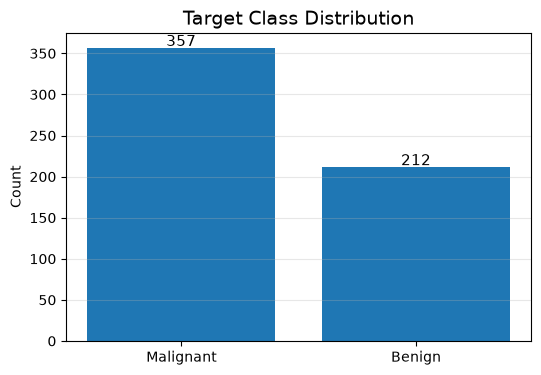

In [5]:
counts = df["Target"].value_counts()

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["Malignant","Benign"],
    counts.values
)

plt.title("Target Class Distribution",fontsize=14)
plt.ylabel("Count")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+2,
        int(bar.get_height()),
        ha="center",
        fontsize=11
    )

plt.grid(axis="y",alpha=0.3)

plt.show()

In [6]:
X = df.drop("Target",axis=1)

y = df["Target"]

In [7]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)

print("Training Samples :",X_train.shape[0])
print("Testing Samples :",X_test.shape[0])

Training Samples : 455
Testing Samples : 114


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [9]:
log_model = LogisticRegression(max_iter=500)

knn_model = KNeighborsClassifier(n_neighbors=5)

tree_model = DecisionTreeClassifier(random_state=42)

svm_model = SVC(
    probability=True,
    random_state=42
)

In [10]:
models = {

    "Logistic Regression":log_model,

    "KNN":knn_model,

    "Decision Tree":tree_model,

    "SVM":svm_model

}

accuracy = {}

for name,model in models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    accuracy[name] = accuracy_score(y_test,pred)

C:\Users\engrf\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [11]:
result = pd.DataFrame({

    "Model":accuracy.keys(),

    "Accuracy":accuracy.values()

})

result.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

result.reset_index(drop=True,inplace=True)

result

,Model,Accuracy
0,Logistic Regression,0.982456
1,SVM,0.982456
2,KNN,0.956140
3,Decision Tree,0.912281


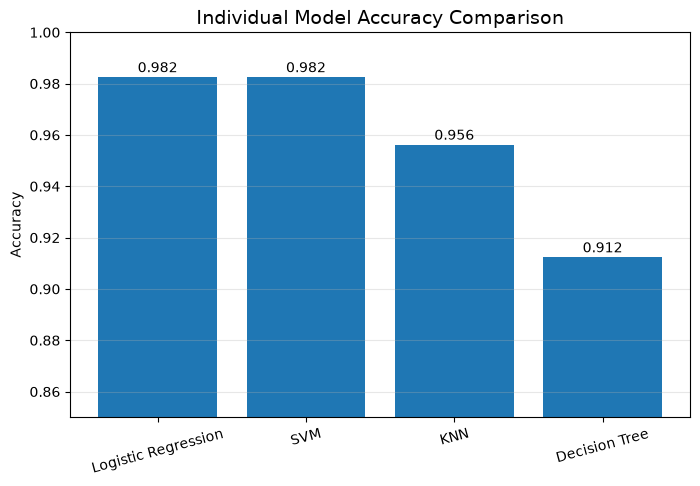

In [12]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    result["Model"],
    result["Accuracy"]
)

plt.title("Individual Model Accuracy Comparison",fontsize=14)

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.ylim(0.85,1)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+0.002,

        f"{bar.get_height():.3f}",

        ha="center",

        fontsize=10

    )

plt.grid(axis="y",alpha=0.3)

plt.show()

In [14]:
best_model = result.iloc[0]

print("="*60)

print("OBSERVATION")

print("="*60)

print(f"\nBest Individual Model : {best_model['Model']}")

print(f"Accuracy : {best_model['Accuracy']:.4f}")

print("\nKey Points")

print("- Logistic Regression performs well on linearly separable data.")
print("- KNN depends on nearest neighbours.")
print("- Decision Tree learns decision rules.")
print("- SVM finds the optimal separating hyperplane.")


OBSERVATION

Best Individual Model : Logistic Regression
Accuracy : 0.9825

Key Points
- Logistic Regression performs well on linearly separable data.
- KNN depends on nearest neighbours.
- Decision Tree learns decision rules.
- SVM finds the optimal separating hyperplane.


# Hard Voting Classifier

In [15]:
hard_voting = VotingClassifier(

    estimators=[

        ("lr", log_model),
        ("knn", knn_model),
        ("dt", tree_model),
        ("svm", svm_model)

    ],

    voting="hard"

)

hard_voting.fit(X_train, y_train)

hard_pred = hard_voting.predict(X_test)

hard_accuracy = accuracy_score(y_test, hard_pred)

print(f"Hard Voting Accuracy : {hard_accuracy:.4f}")

Hard Voting Accuracy : 0.9825


C:\Users\engrf\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [16]:
soft_voting = VotingClassifier(

    estimators=[

        ("lr", log_model),
        ("knn", knn_model),
        ("dt", tree_model),
        ("svm", svm_model)

    ],

    voting="soft"

)

soft_voting.fit(X_train, y_train)

soft_pred = soft_voting.predict(X_test)

soft_accuracy = accuracy_score(y_test, soft_pred)

print(f"Soft Voting Accuracy : {soft_accuracy:.4f}")

Soft Voting Accuracy : 0.9737


C:\Users\engrf\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [17]:
soft_voting = VotingClassifier(

    estimators=[

        ("lr", log_model),
        ("knn", knn_model),
        ("dt", tree_model),
        ("svm", svm_model)

    ],

    voting="soft"

)

soft_voting.fit(X_train, y_train)

soft_pred = soft_voting.predict(X_test)

soft_accuracy = accuracy_score(y_test, soft_pred)

print(f"Soft Voting Accuracy : {soft_accuracy:.4f}")

Soft Voting Accuracy : 0.9737


C:\Users\engrf\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [18]:
comparison = result.copy()

comparison.loc[len(comparison)] = ["Hard Voting", hard_accuracy]

comparison.loc[len(comparison)] = ["Soft Voting", soft_accuracy]

comparison = comparison.sort_values(

    by="Accuracy",
    ascending=False

).reset_index(drop=True)

comparison

,Model,Accuracy
0,Logistic Regression,0.982456
1,SVM,0.982456
2,Hard Voting,0.982456
3,Soft Voting,0.973684
4,KNN,0.956140
5,Decision Tree,0.912281


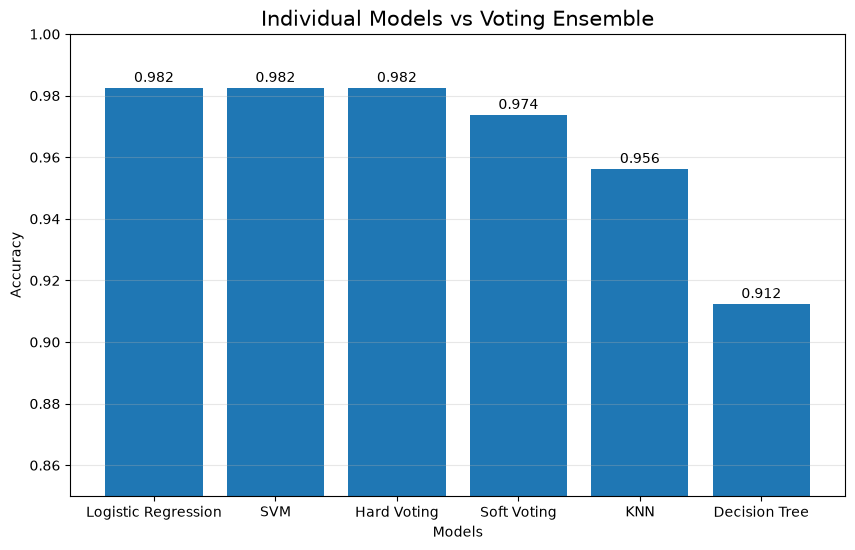

In [19]:
plt.figure(figsize=(10,6))

bars = plt.bar(

    comparison["Model"],
    comparison["Accuracy"]

)

plt.title("Individual Models vs Voting Ensemble", fontsize=15)

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0.85,1.0)

plt.grid(axis="y", alpha=0.3)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+0.002,

        f"{bar.get_height():.3f}",

        ha="center",

        fontsize=10

    )

plt.show()

In [20]:
best = comparison.iloc[0]

print("="*60)

print("BEST MODEL")

print("="*60)

print()

print("Model :", best["Model"])

print(f"Accuracy : {best['Accuracy']:.4f}")

BEST MODEL

Model : Logistic Regression
Accuracy : 0.9825


In [21]:
print("="*60)

print("OBSERVATIONS")

print("="*60)

print()

print("1. Individual models perform differently because")
print("   each algorithm learns data differently.")

print()

print("2. Hard Voting combines predicted class labels")
print("   using majority voting.")

print()

print("3. Soft Voting combines prediction probabilities.")
print("   Therefore, it usually performs better.")

print()

print("4. Ensemble Learning reduces dependence on")
print("   a single machine learning model.")

print()

print("5. If Soft Voting gives the best accuracy,")
print("   it indicates probability averaging")
print("   improved the final prediction.")

OBSERVATIONS

1. Individual models perform differently because
   each algorithm learns data differently.

2. Hard Voting combines predicted class labels
   using majority voting.

3. Soft Voting combines prediction probabilities.
   Therefore, it usually performs better.

4. Ensemble Learning reduces dependence on
   a single machine learning model.

5. If Soft Voting gives the best accuracy,
   it indicates probability averaging
   improved the final prediction.


In [22]:
new_samples = X_test[:5]

predictions = pd.DataFrame({

    "Actual": y_test.iloc[:5].values,

    "Hard Voting": hard_voting.predict(new_samples),

    "Soft Voting": soft_voting.predict(new_samples)

})

predictions

,Actual,Hard Voting,Soft Voting
0,0,0,0
1,1,1,1
2,0,0,0
3,1,1,1
4,0,0,0


In [23]:
prob = pd.DataFrame(

    soft_voting.predict_proba(new_samples),

    columns=["Malignant","Benign"]

)

prob

,Malignant,Benign
0,0.999660,0.000340
1,0.000003,0.999997
2,0.996227,0.003773
3,0.375739,0.624261
4,0.998459,0.001541


In [24]:
summary = pd.DataFrame({

    "Model":[

        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "SVM",
        "Hard Voting",
        "Soft Voting"

    ],

    "Accuracy":[

        accuracy["Logistic Regression"],
        accuracy["KNN"],
        accuracy["Decision Tree"],
        accuracy["SVM"],
        hard_accuracy,
        soft_accuracy

    ]

})

summary = summary.sort_values(

    by="Accuracy",

    ascending=False

).reset_index(drop=True)

summary

,Model,Accuracy
0,Logistic Regression,0.982456
1,SVM,0.982456
2,Hard Voting,0.982456
3,Soft Voting,0.973684
4,KNN,0.956140
5,Decision Tree,0.912281
